In [21]:
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.utils import load_img, img_to_array
from numpy import expand_dims
from keras.applications.vgg16 import preprocess_input


In [31]:
# Loading the model
base_model = VGG16()


In [32]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# pip install pydot graphviz


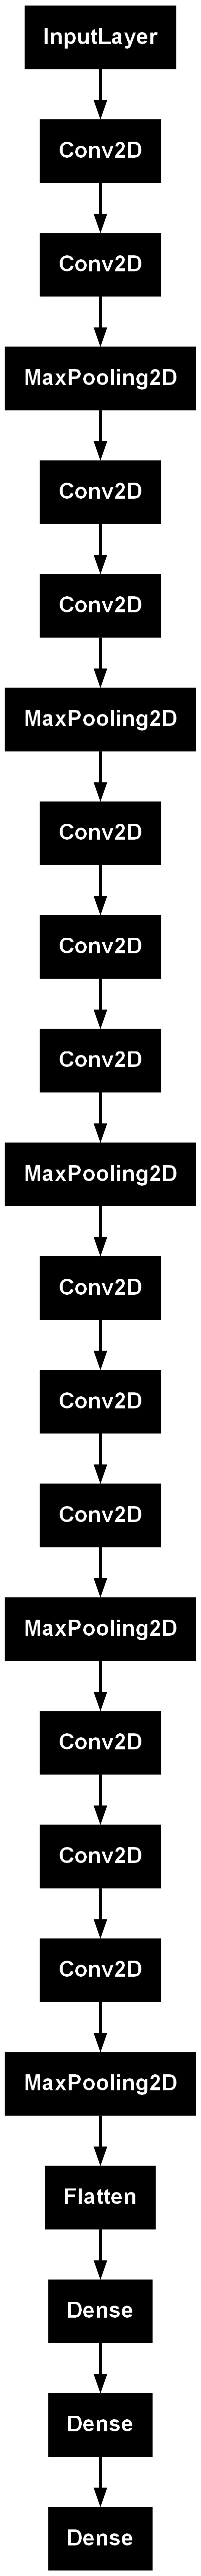

In [34]:

from keras.utils import plot_model

plot_model(base_model)

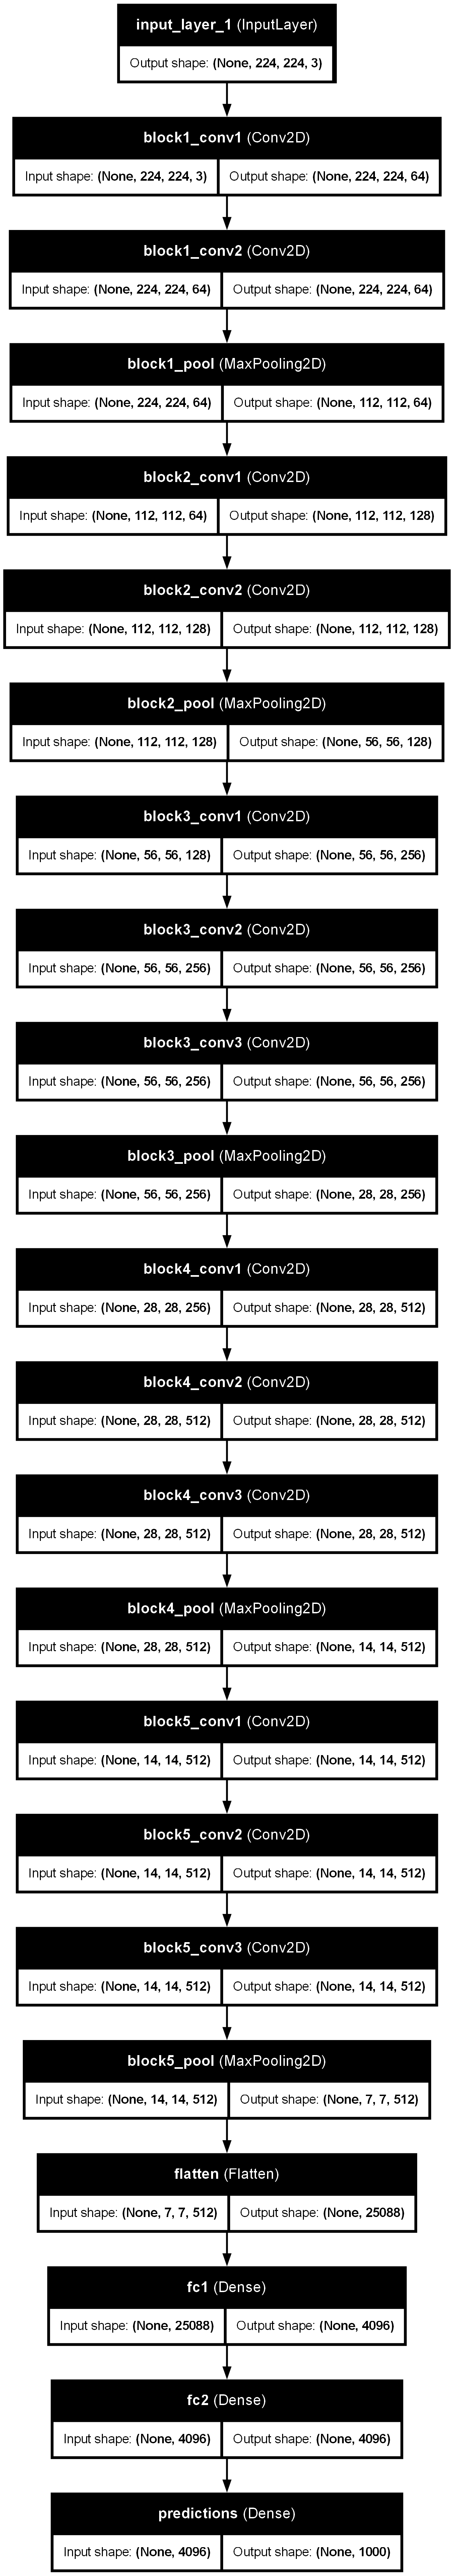

In [35]:
from keras.utils import plot_model

plot_model(
    base_model,
    to_file="resnet50.png",
    show_shapes=True,
    show_layer_names=True
)


In [36]:
for i in range(len(base_model.layers)):
    # Chack for convolutional layers
    if 'conv' not in base_model.layers[i].name:
        continue
    # get filters weights
    filters , biases = base_model.layers[i].get_weights()
    print("layer number", i , base_model.layers[i].name, filters.shape)

layer number 1 block1_conv1 (3, 3, 3, 64)
layer number 2 block1_conv2 (3, 3, 64, 64)
layer number 4 block2_conv1 (3, 3, 64, 128)
layer number 5 block2_conv2 (3, 3, 128, 128)
layer number 7 block3_conv1 (3, 3, 128, 256)
layer number 8 block3_conv2 (3, 3, 256, 256)
layer number 9 block3_conv3 (3, 3, 256, 256)
layer number 11 block4_conv1 (3, 3, 256, 512)
layer number 12 block4_conv2 (3, 3, 512, 512)
layer number 13 block4_conv3 (3, 3, 512, 512)
layer number 15 block5_conv1 (3, 3, 512, 512)
layer number 16 block5_conv2 (3, 3, 512, 512)
layer number 17 block5_conv3 (3, 3, 512, 512)


In [37]:
# retrieve weights from the second hidden layer
filters , bias = base_model.layers[1].get_weights()

In [38]:
# # Normalize filter value to 0-1 so we can visualize them
f_min , f_max = filters.min() , filters.max()
filters = (filters - f_min) / (f_max - f_min)

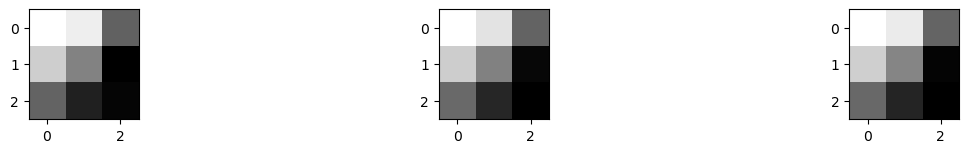

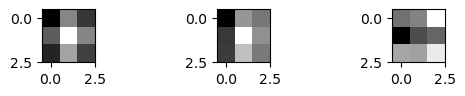

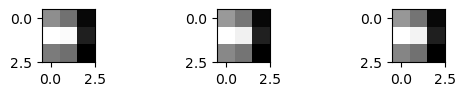

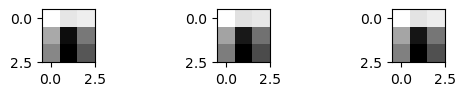

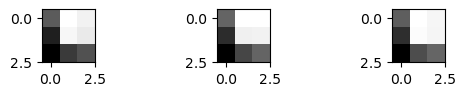

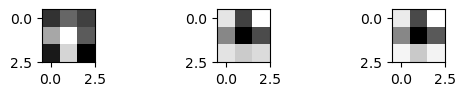

In [39]:
from matplotlib import pyplot
n_filters = 6
ix = 1
fig = pyplot.figure(figsize=(15,10))
for i in range(n_filters):
    # get the filters
    f = filters[:,:,:,i]
    for j in range(3):
        # Subplot for 6 filters and 3 channels
        pyplot.subplot(n_filters , 3 , ix)
        pyplot.imshow(f[:,:,j] , cmap='gray')
        ix += 1
    # plot the filters
    pyplot.show()

In [40]:
model = Model(inputs=base_model.inputs , outputs=base_model.layers[1].output)

In [41]:
image = load_img(r"D:\JUPYTER NOTEBOOK\DEEP LEARNING\DL Notebooks\Pretrained_model\buffalo.jpg", target_size=(224,224))
# convert the image to an array
image = img_to_array(image)
# expand dimensions so that it represents  a single 'sample' 
image = expand_dims(image , axis=0)
image = preprocess_input(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


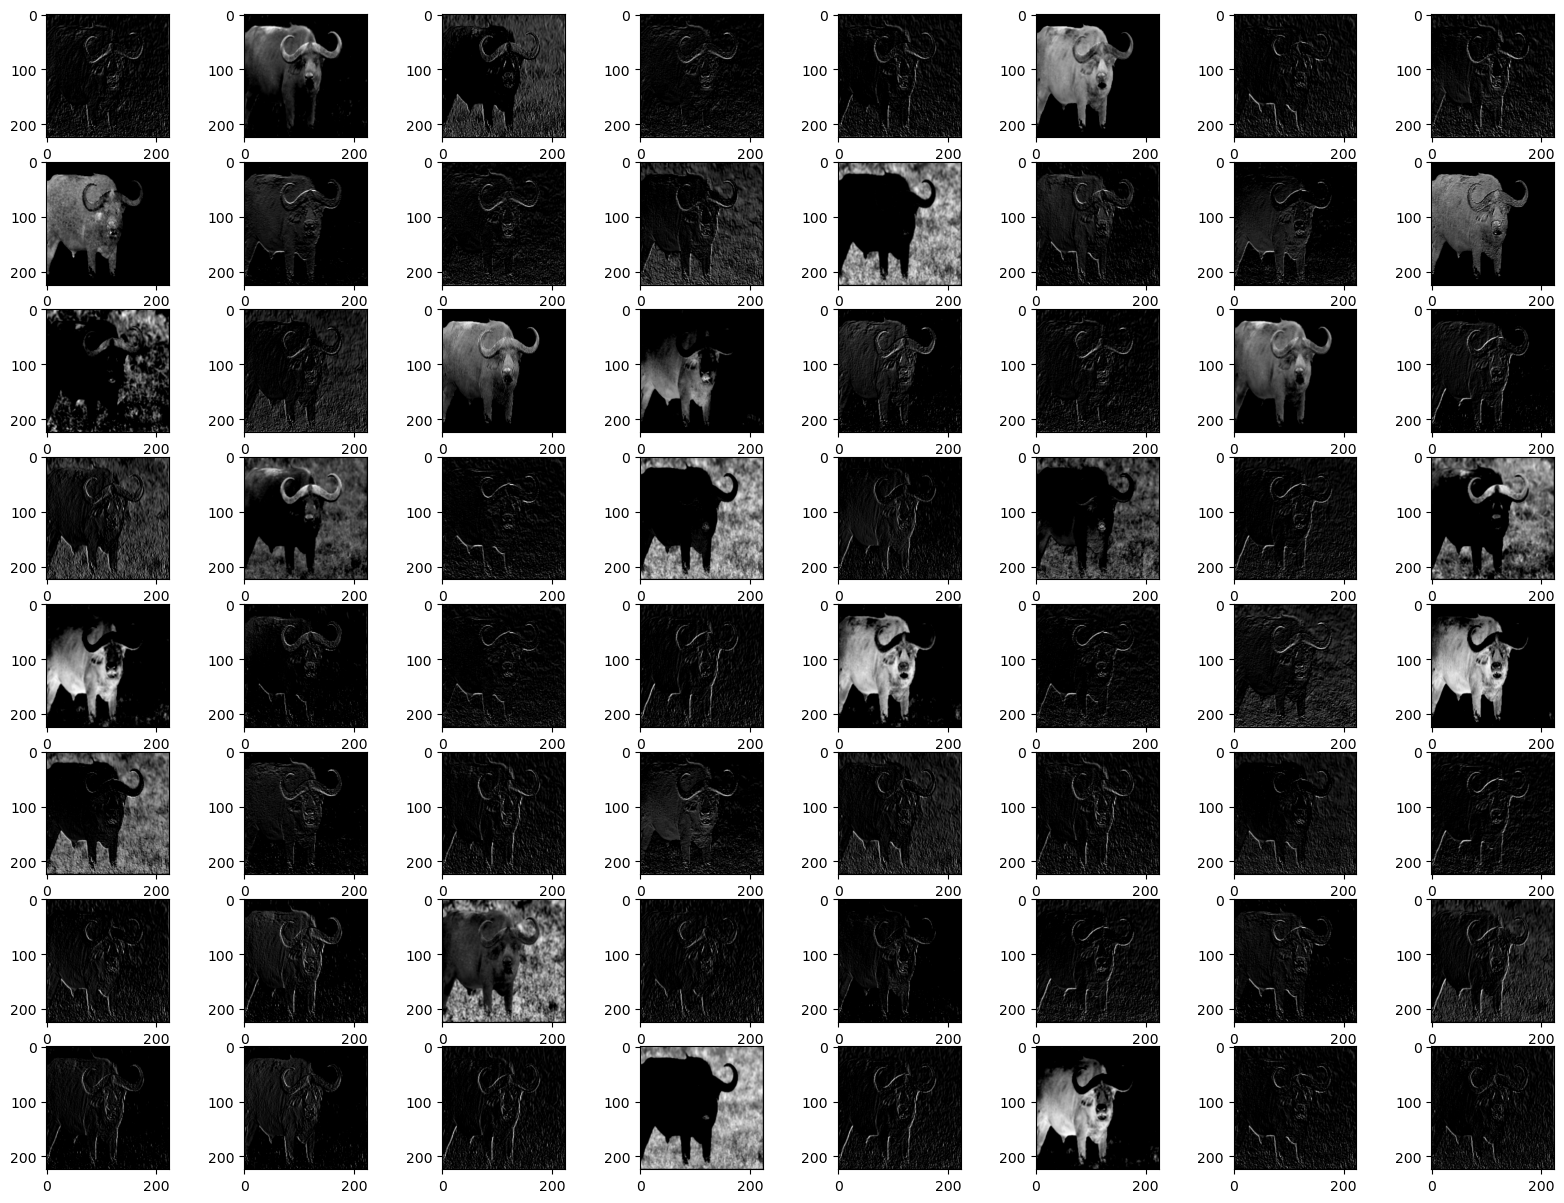

In [42]:
# calculating features_map
features = model.predict(image)
fig = pyplot.figure(figsize=(20,15))
for i in range(1, features.shape[3]+1):
    pyplot.subplot(8,8,i)
    pyplot.imshow(features[0,:,:,i-1] , cmap='gray')

pyplot.show()

In [ ]:
# 64 image because of 64 filter when passed through first layers

In [28]:
print(features.shape)


(1, 224, 224, 64)


In [46]:
# Visualizing the deeper layers
from keras.models import Model

deep_model = Model(
    inputs=base_model.inputs,
    outputs=base_model.layers[5].output
)


In [47]:
feature_maps = deep_model.predict(image)
print(feature_maps.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
(1, 112, 112, 128)


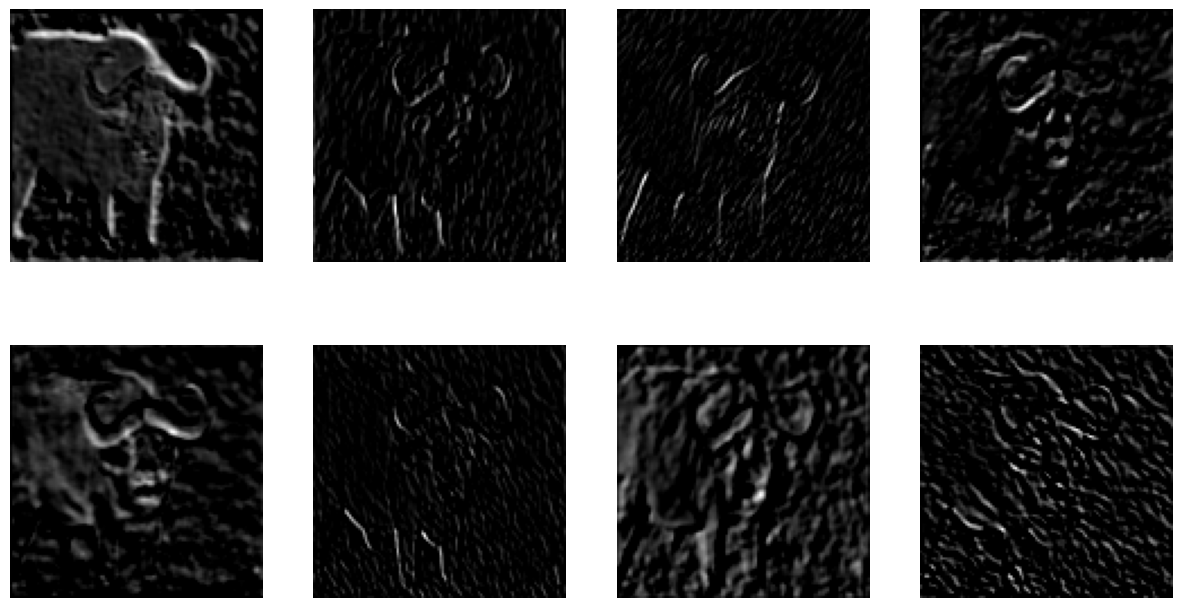

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i in range(8):   # show first 8 filters
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.axis("off")

plt.show()


In [50]:
model2 = VGG16()

In [51]:
layer_index = [2 , 5 , 9 , 13 , 17]
outputs = [model2.layers[i].output for i in layer_index]

model3 = Model(inputs = model2.inputs , outputs = outputs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


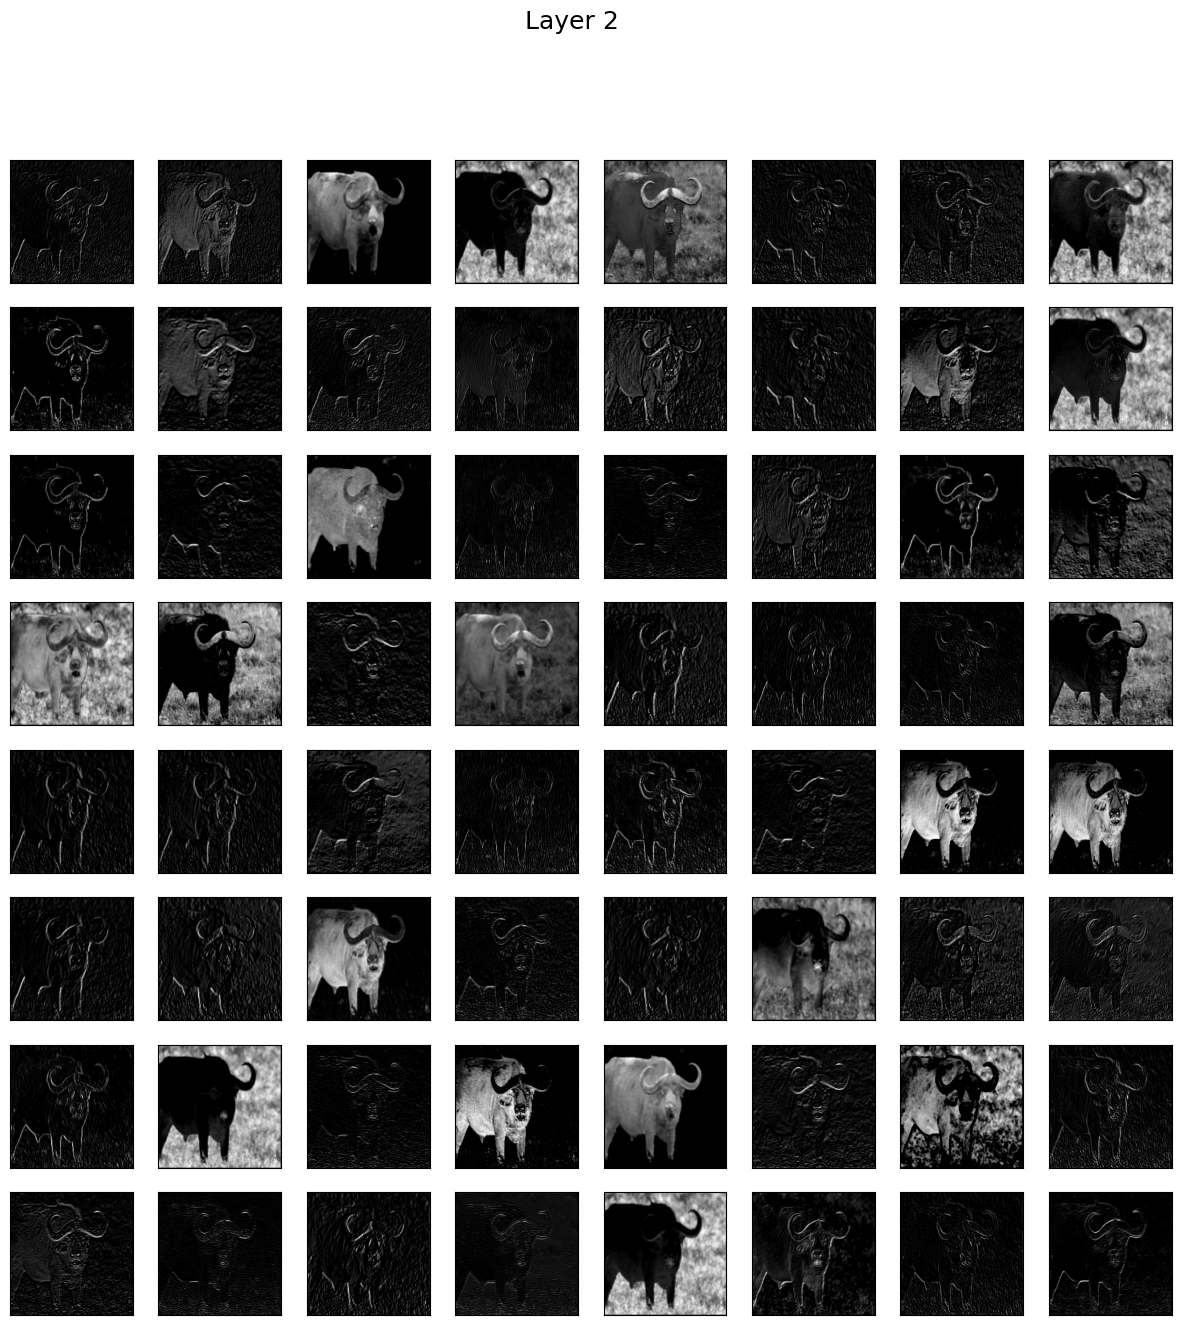

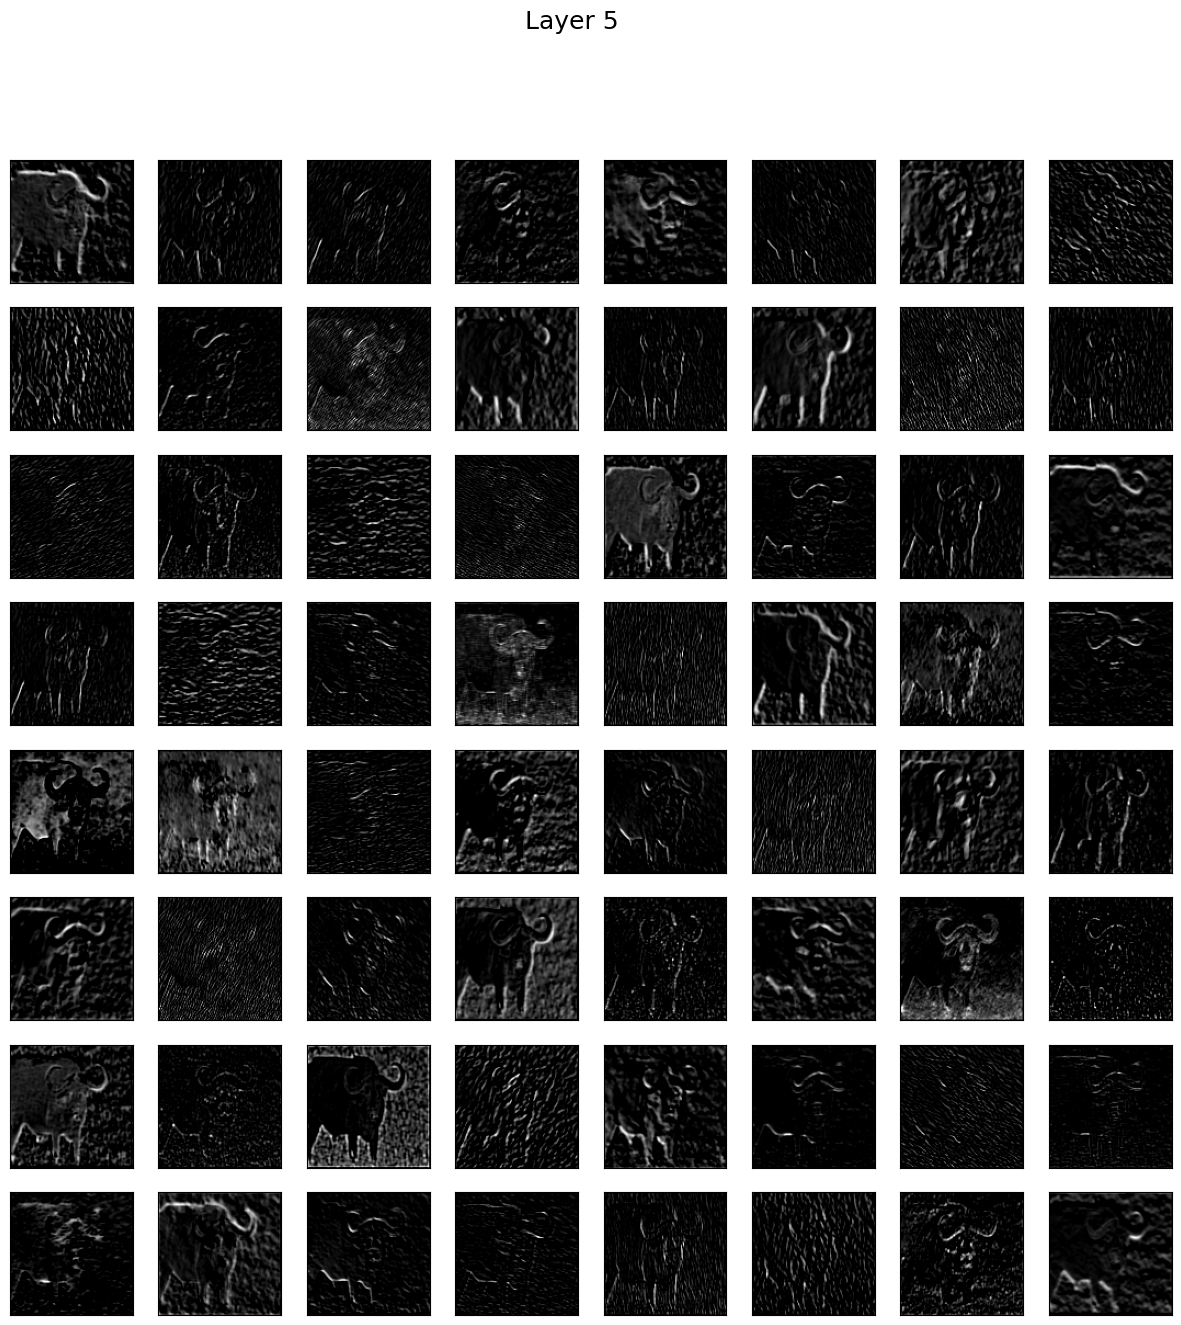

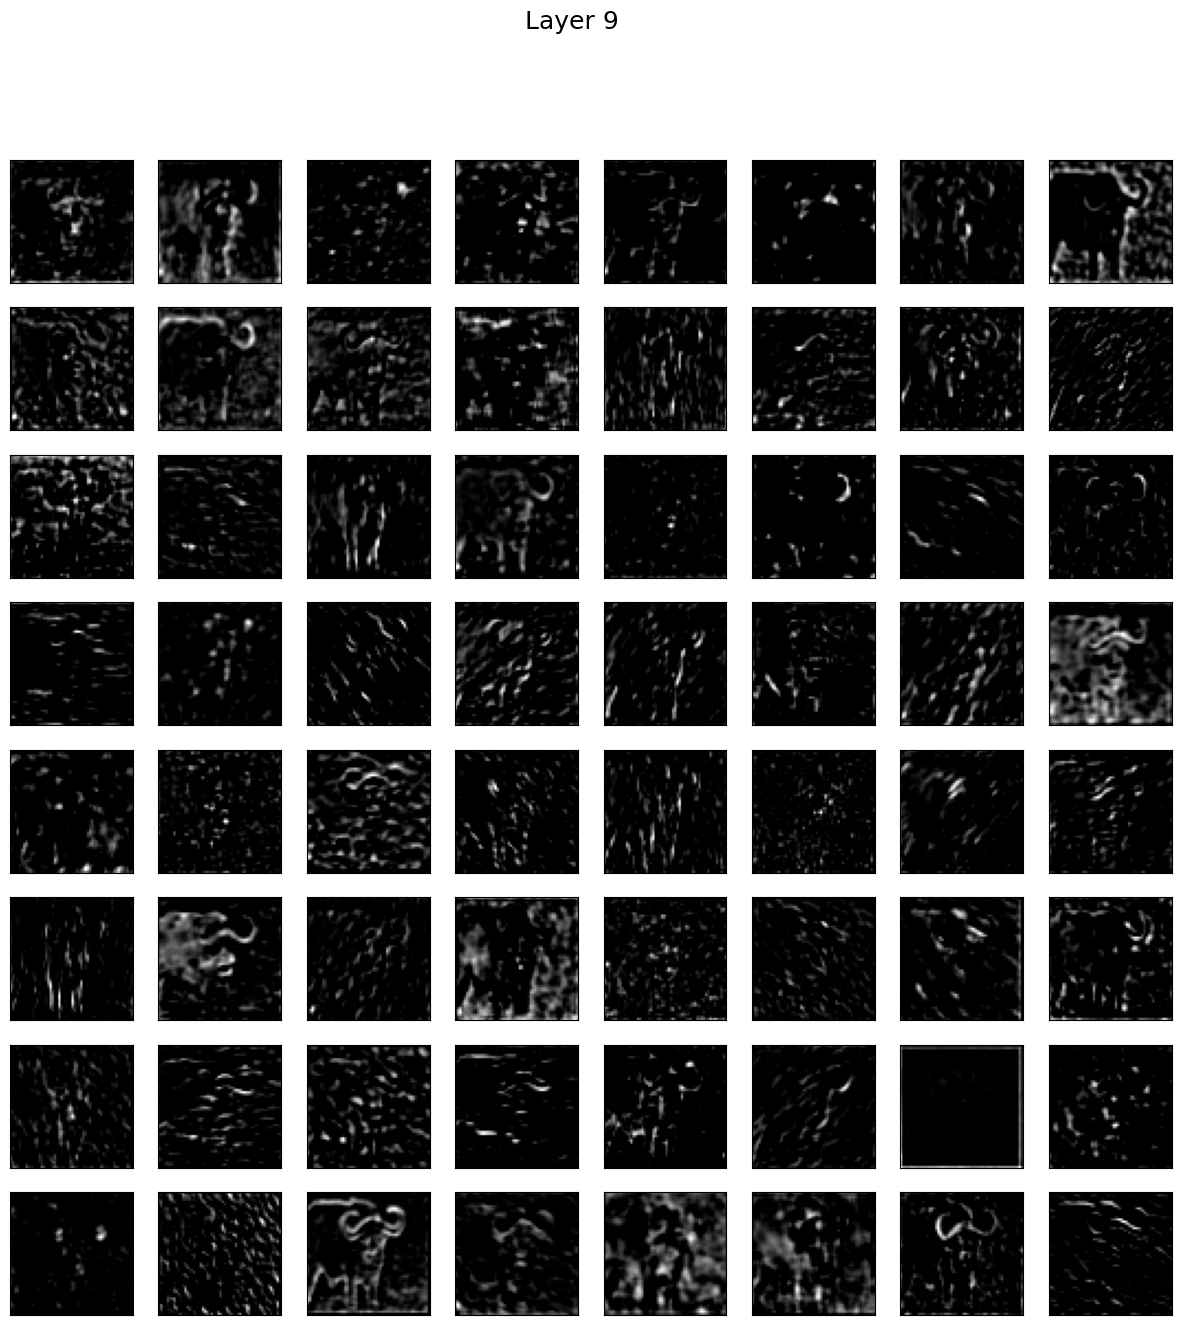

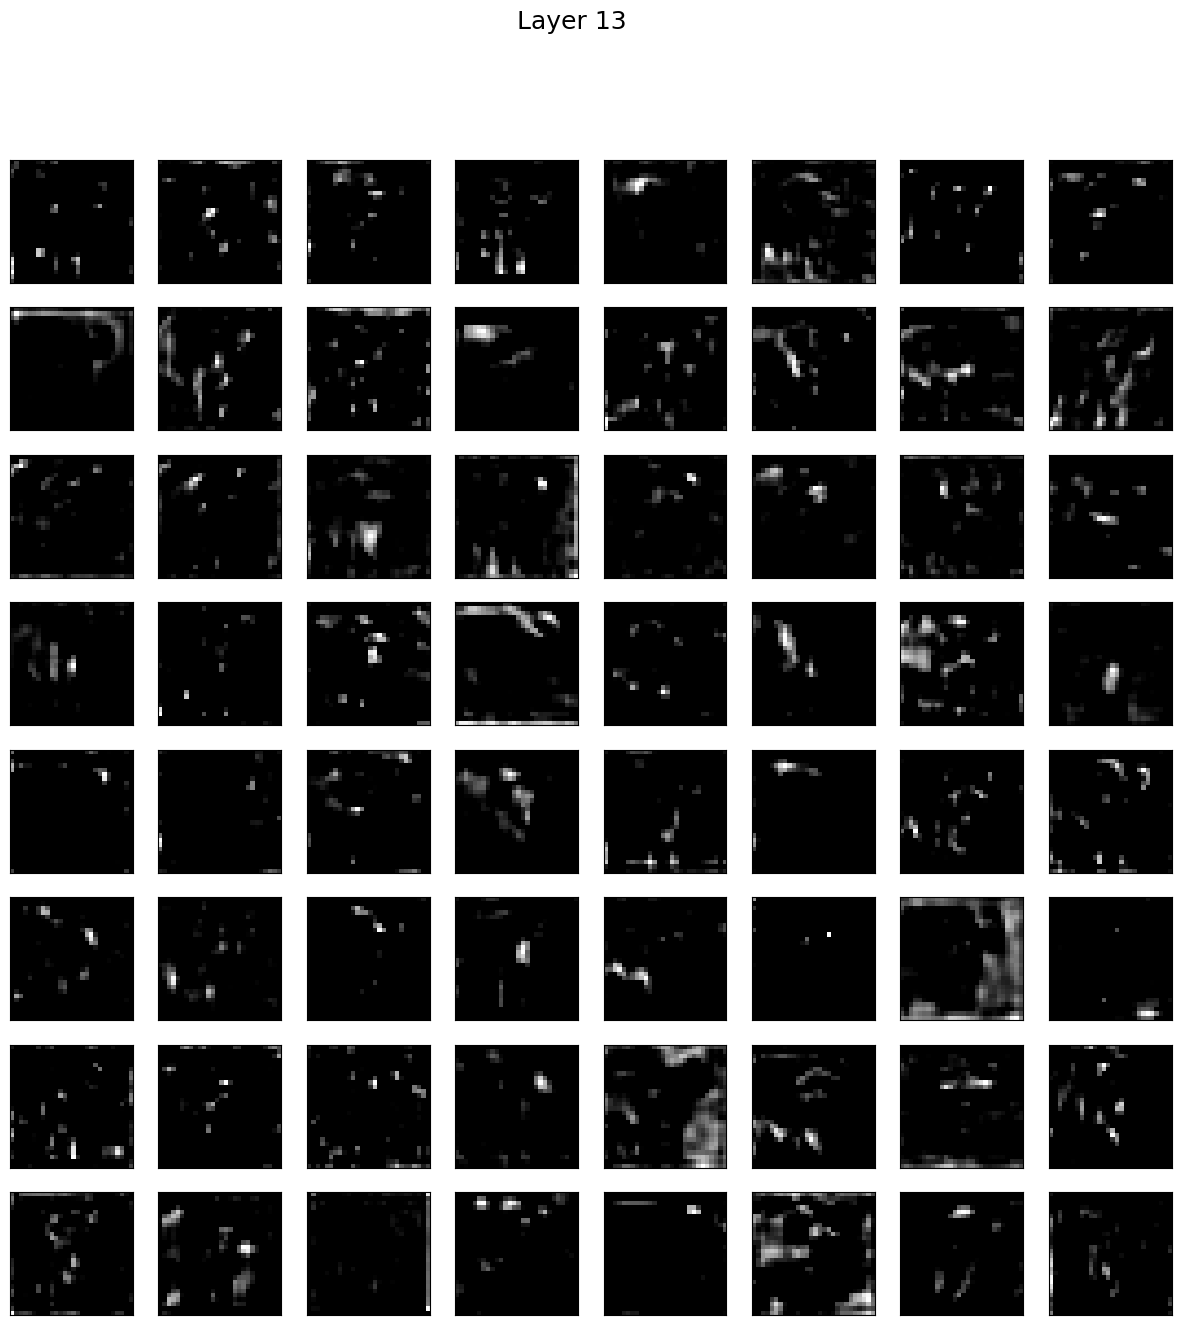

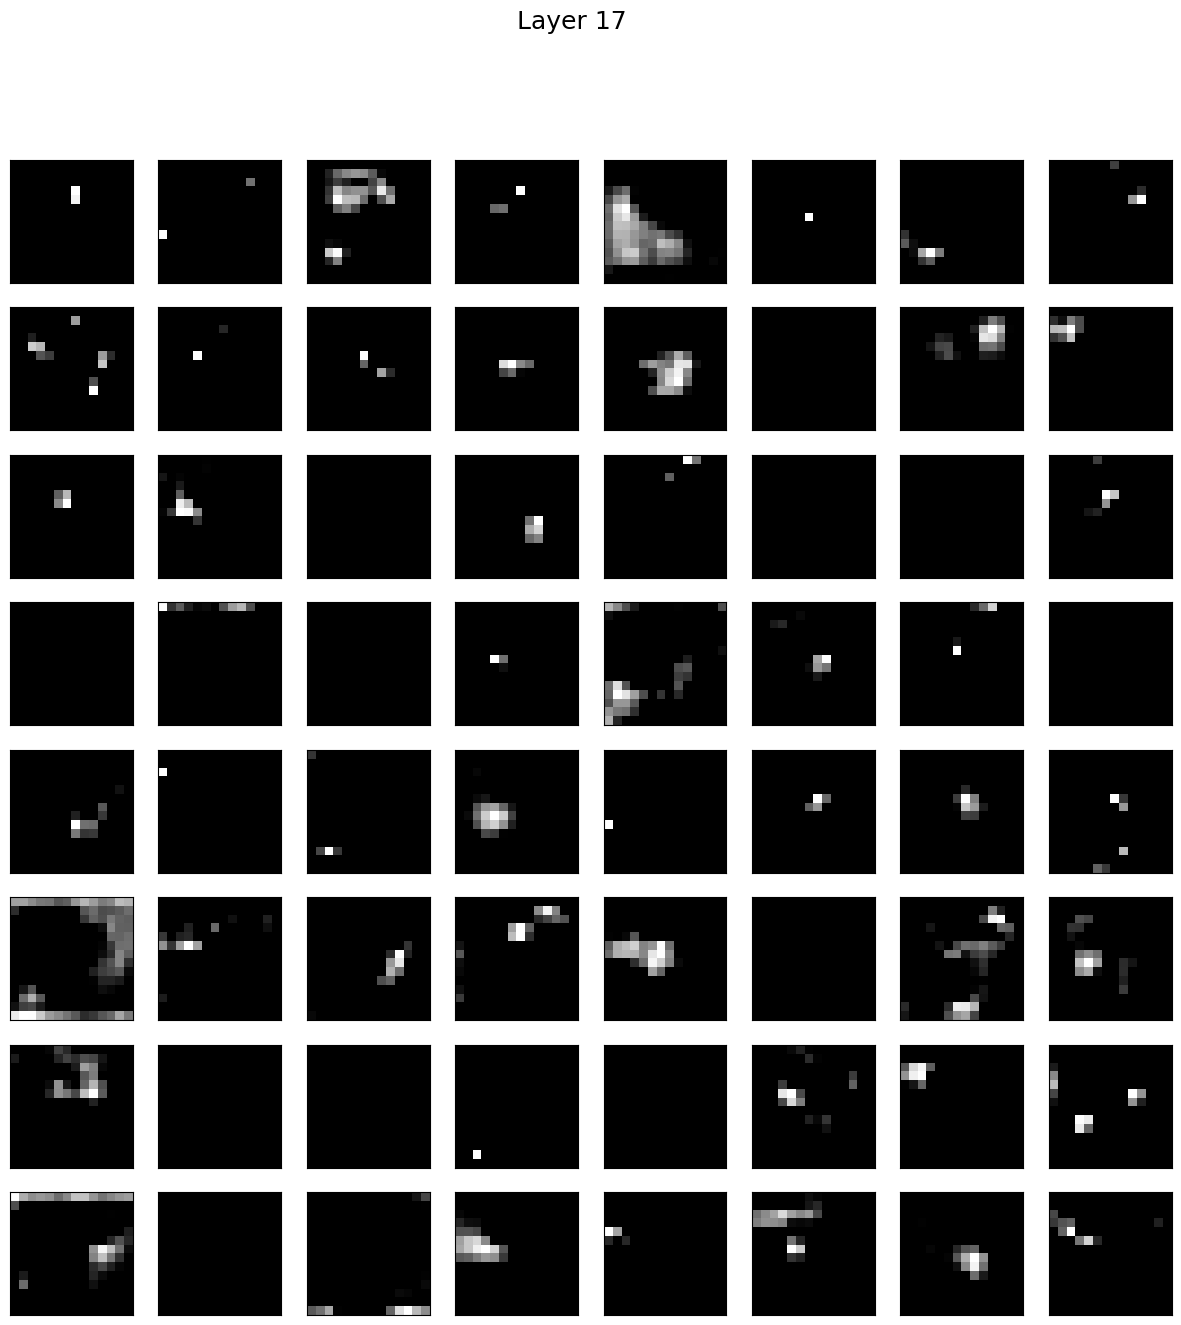

In [55]:
from matplotlib import pyplot as plt

feature_maps = model3.predict(image)

for layer_id, fmap in zip(layer_index, feature_maps):
    n_features = fmap.shape[-1]
    n_display = min(64, n_features)

    plt.figure(figsize=(15, 15))
    plt.suptitle(f"Layer {layer_id}", fontsize=18)

    for i in range(n_display):
        ax = plt.subplot(8, 8, i + 1)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(fmap[0, :, :, i], cmap="gray")

    plt.show()
